In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

In [2]:
df = pd.read_csv('Air Traffic Data Updated.csv')
df.head()

,Date,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Population,Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate,Rupees Exchange Rate
0,01-01-2009,3288004,885435,20832,11675,1.341888e+12,1225524753,71.75,10.88,7.66,48.70
1,01-02-2009,3293220,757168,18645,12482,1.341888e+12,1225524753,61.97,10.88,7.66,49.25
2,01-03-2009,3122400,848046,23046,15359,1.341888e+12,1225524753,65.01,10.88,7.66,51.13
3,01-04-2009,3266686,861715,21623,14512,1.341888e+12,1225524753,68.55,10.88,7.66,49.97
4,01-05-2009,3883887,898410,19534,14586,1.341888e+12,1225524753,72.22,10.88,7.66,48.51


 Fitting the SARIMA Model to the data

In [3]:
y = df['domestic passengers']

In [4]:
train = y[:-12]
test = y[-12:]

In [5]:
model = SARIMAX(train,order=(2,1,2),seasonal_order=(0,0,1,12))
sarima_fit = model.fit(disp=False)

In [6]:
#Forecast

forecast = sarima_fit.get_forecast(steps=len(test))
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

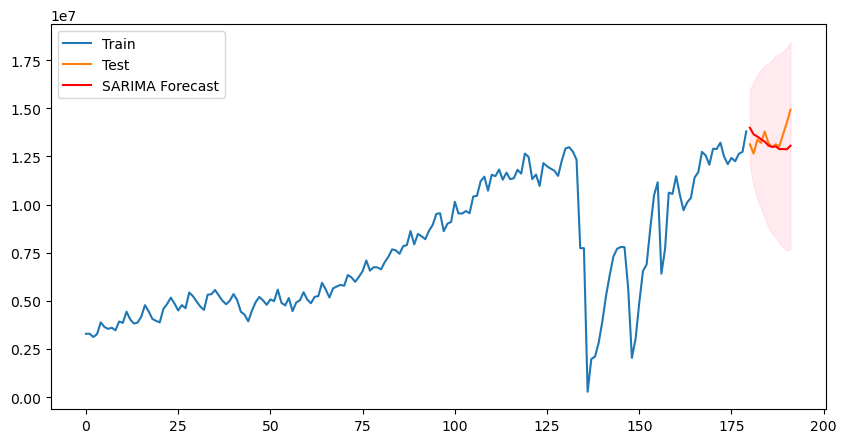

In [7]:
# Plot

plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred, label="SARIMA Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.show()

In [8]:
mae = mean_absolute_error(test,pred)
mse = mean_squared_error(test,pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test-pred)/test))* 100

In [9]:
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 596896.47
MSE: 677920470574.33
RMSE: 823359.26
MAPE: 4.32%


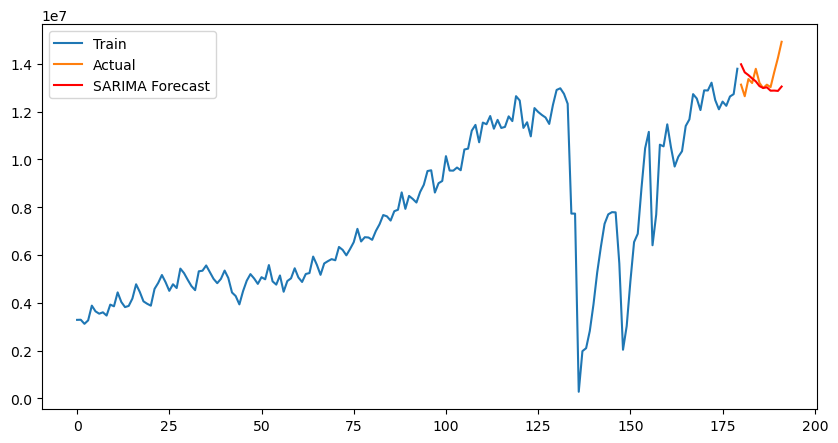

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(pred, label="SARIMA Forecast", color="red")
plt.legend()
plt.show()

Finding the best model parameters using auto_arima



In [ ]:
stepwise_fit = auto_arima(
    y, 
    seasonal=True, m=12,   # m=12 → monthly data with yearly seasonality
    trace=True,            # shows progress
    error_action="ignore",
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=5807.187, Time=0.90 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=5817.707, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=5810.874, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=5809.543, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=5816.439, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=5805.250, Time=0.78 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=5817.012, Time=0.34 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=5807.185, Time=2.36 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=5806.651, Time=0.60 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=5809.340, Time=1.97 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=5810.618, Time=0.24 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=5810.479, Time=0.24 sec
 ARIMA(3,1,2)(0,0,1)[12] intercept   : AIC=5811.115, Time=0.37 sec
 ARIMA(2,1,3)(0,0,1)[12] intercept   : AIC=5810.758, Time=0.83 sec
 ARIMA(1,1,1)(0,0,1

In [12]:
print(stepwise_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  192
Model:             SARIMAX(2, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -2895.625
Date:                              Thu, 18 Sep 2025   AIC                           5805.250
Time:                                      00:35:13   BIC                           5828.016
Sample:                                           0   HQIC                          5814.471
                                              - 192                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   6.108e+04   6.67e-09   9.16e+12      0.000    6.11e+04    6.11e+04
ar.L1         -0.91